In [1]:
import pandas as pd
import numpy as np
import seaborn as sns


In [2]:
df_train=pd.read_csv("train.csv")
df_test=pd.read_csv("test.csv")

In [3]:
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
df_train.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [6]:
df_test.columns


Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [113]:
df_train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   float64
 1   MSSubClass     1460 non-null   float64
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   float64
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   float64
 18  OverallC

In [114]:
df_test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461.0,20.0,RH,80.0,11622.0,Pave,NaN,Reg,Lvl,AllPub,...,1.200000e+02,1.520853e-17,NaN,MnPrv,NaN,4.562560e-18,6.0,2010.0,WD,Normal
1,1462.0,20.0,RL,81.0,14267.0,Pave,NaN,IR1,Lvl,AllPub,...,-1.216683e-17,1.520853e-17,NaN,NaN,Gar2,1.250000e+04,6.0,2010.0,WD,Normal
2,1463.0,60.0,RL,74.0,13830.0,Pave,NaN,IR1,Lvl,AllPub,...,-1.216683e-17,1.520853e-17,NaN,MnPrv,NaN,4.562560e-18,3.0,2010.0,WD,Normal
3,1464.0,60.0,RL,78.0,9978.0,Pave,NaN,IR1,Lvl,AllPub,...,-1.216683e-17,1.520853e-17,NaN,NaN,NaN,4.562560e-18,6.0,2010.0,WD,Normal
4,1465.0,120.0,RL,43.0,5005.0,Pave,NaN,IR1,HLS,AllPub,...,1.440000e+02,1.520853e-17,NaN,NaN,NaN,4.562560e-18,1.0,2010.0,WD,Normal


In [30]:
df_train.isnull().sum().sort_values(ascending=False)
df_train.describe()
X=df_train.drop("SalePrice",axis=1)
y=df_train["SalePrice"]
X.head()
y.head()

0    208500.0
1    181500.0
2    223500.0
3    140000.0
4    250000.0
Name: SalePrice, dtype: float64

In [31]:
X.isnull().sum()

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MiscVal          0
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
Length: 80, dtype: int64

In [32]:
cat_col=X.select_dtypes(include="object").columns
num_col=X.select_dtypes(include=["float64","int64"]).columns

In [33]:

from sklearn.impute import SimpleImputer
si=SimpleImputer(strategy='mean')
X[num_col]=si.fit_transform(X[num_col])

In [34]:
sim=SimpleImputer(strategy='most_frequent')
X[cat_col]=sim.fit_transform(X[cat_col])

In [36]:
X.isnull().sum().sort_values(ascending=False)

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MiscVal          0
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
Length: 80, dtype: int64

In [39]:
#one hot encoding
X=pd.get_dummies(X,columns=cat_col,drop_first=True)

In [41]:
X.head(20)
X.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 245 entries, Id to SaleCondition_Partial
dtypes: bool(208), float64(37)
memory usage: 718.7 KB


In [43]:
from sklearn.model_selection import train_test_split
X_train,X_valid,y_train,y_valid=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train[num_col]=sc.fit_transform(X_train[num_col])
X_valid[num_col]=sc.transform(X_valid[num_col])


In [71]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [72]:
y_pred=lr.predict(X_valid)
y_pred

array([ 157801.18216784,  349340.85325807,   86498.71780403,
        173972.18425209,  317563.56247628,   66677.11795548,
        235613.88277165,  146365.46029237,   57710.7546514 ,
        153922.23594401,  144439.48446557,  105490.3129261 ,
         81108.89310056,  220418.56358196,  173967.59517745,
        133408.46241281,  186405.59555882,  128722.00804307,
        130267.32447943,  216550.17149346,  148593.56363238,
        204172.59379834,  170710.50376904,  128174.24588354,
        197214.12514984,  134970.88219196,  191505.55559992,
        101384.94082721,  175290.14784681,  203957.20699852,
        170213.17269447,  277639.01016705,  240106.43316973,
        109593.97017384,  237273.13036923,  151458.60958128,
        128952.88924044,  200628.24285225,  308679.8822464 ,
        106045.56518724,  116794.14312378,  218808.91152248,
        101823.46820779,  371735.61038532,  132666.65675816,
        142609.2972727 ,   96915.48811668,  139884.33593391,
        424936.57350145,

In [52]:
y_valid

892     154500.0
1105    325000.0
413     115000.0
522     159000.0
1036    315500.0
          ...   
479      89471.0
1361    260000.0
802     189000.0
651     108000.0
722     124500.0
Name: SalePrice, Length: 292, dtype: float64

In [73]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



print("MAE :", mean_absolute_error(y_valid, y_pred))
print("MSE :", mean_squared_error(y_valid, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_valid, y_pred)))
print("R2  :", r2_score(y_valid, y_pred))

MAE : 20230.0854157375
MSE : 2641638813.2246966
RMSE: 51396.8755200615
R2  : 0.6556028072509523


In [64]:

from sklearn.linear_model import RidgeCV
a=[0.01,0.1,2,5,20,30,50,100]
rcv=RidgeCV(
    alphas=a,
    cv=5
)
rcv.fit(X_train,y_train)
y_pred=rcv.predict(X_valid)
print("MAE :", mean_absolute_error(y_valid, y_pred))
print("MSE :", mean_squared_error(y_valid, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_valid, y_pred)))
print("R2  :", r2_score(y_valid, y_pred))
print("best alpha",rcv.alpha_)

MAE : 18566.994610131267
MSE : 976691706.2868264
RMSE: 31252.067232214038
R2  : 0.8726662100274611
best alpha 20.0


In [68]:

from sklearn.linear_model import LassoCV
a=[0.01,0.1,2,5,20,30,50,100]
lcv=LassoCV(
    alphas=a,
    max_iter=500,
    cv=5
)
lcv.fit(X_train,y_train)
y_pred=lcv.predict(X_valid)
print("MAE :", mean_absolute_error(y_valid, y_pred))
print("MSE :", mean_squared_error(y_valid, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_valid, y_pred)))
print("R2  :", r2_score(y_valid, y_pred))
print("best alpha",rcv.alpha_)

c:\Users\ADMIN\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.477e+09, tolerance: 5.374e+08
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\ADMIN\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.056e+10, tolerance: 5.374e+08
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\ADMIN\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, che

MAE : 18666.1647334725
MSE : 931226308.9929588
RMSE: 30516.000868281524
R2  : 0.8785936498867029
best alpha 20.0


c:\Users\ADMIN\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.472e+11, tolerance: 5.796e+08
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\ADMIN\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.639e+11, tolerance: 5.796e+08
  model = cd_fast.enet_coordinate_descent_gram(


In [74]:

from sklearn.linear_model import ElasticNetCV
a=[0.01,0.1,2,5,20,30,50,100]
eln=RidgeCV(
    alphas=a,
    cv=5
)
eln.fit(X_train,y_train)
y_pred=eln.predict(X_valid)
print("MAE :", mean_absolute_error(y_valid, y_pred))
print("MSE :", mean_squared_error(y_valid, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_valid, y_pred)))
print("R2  :", r2_score(y_valid, y_pred))
print("best alpha",rcv.alpha_)

MAE : 18566.994610131267
MSE : 976691706.2868264
RMSE: 31252.067232214038
R2  : 0.8726662100274611
best alpha 20.0


In [ ]:
from sklearn.tree import DecisionTreeRegressor
dtr=DecisionTreeRegressor()
dtr.fit(X_train,y_train)
y_pred=dtr.predict(X_valid)
print("MAE :", mean_absolute_error(y_valid, y_pred))
print("MSE :", mean_squared_error(y_valid, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_valid, y_pred)))
print("R2  :", r2_score(y_valid, y_pred))




MAE : 27678.979452054795
MSE : 1722993412.2054794
RMSE: 41508.95580721682
R2  : 0.7753689522890137


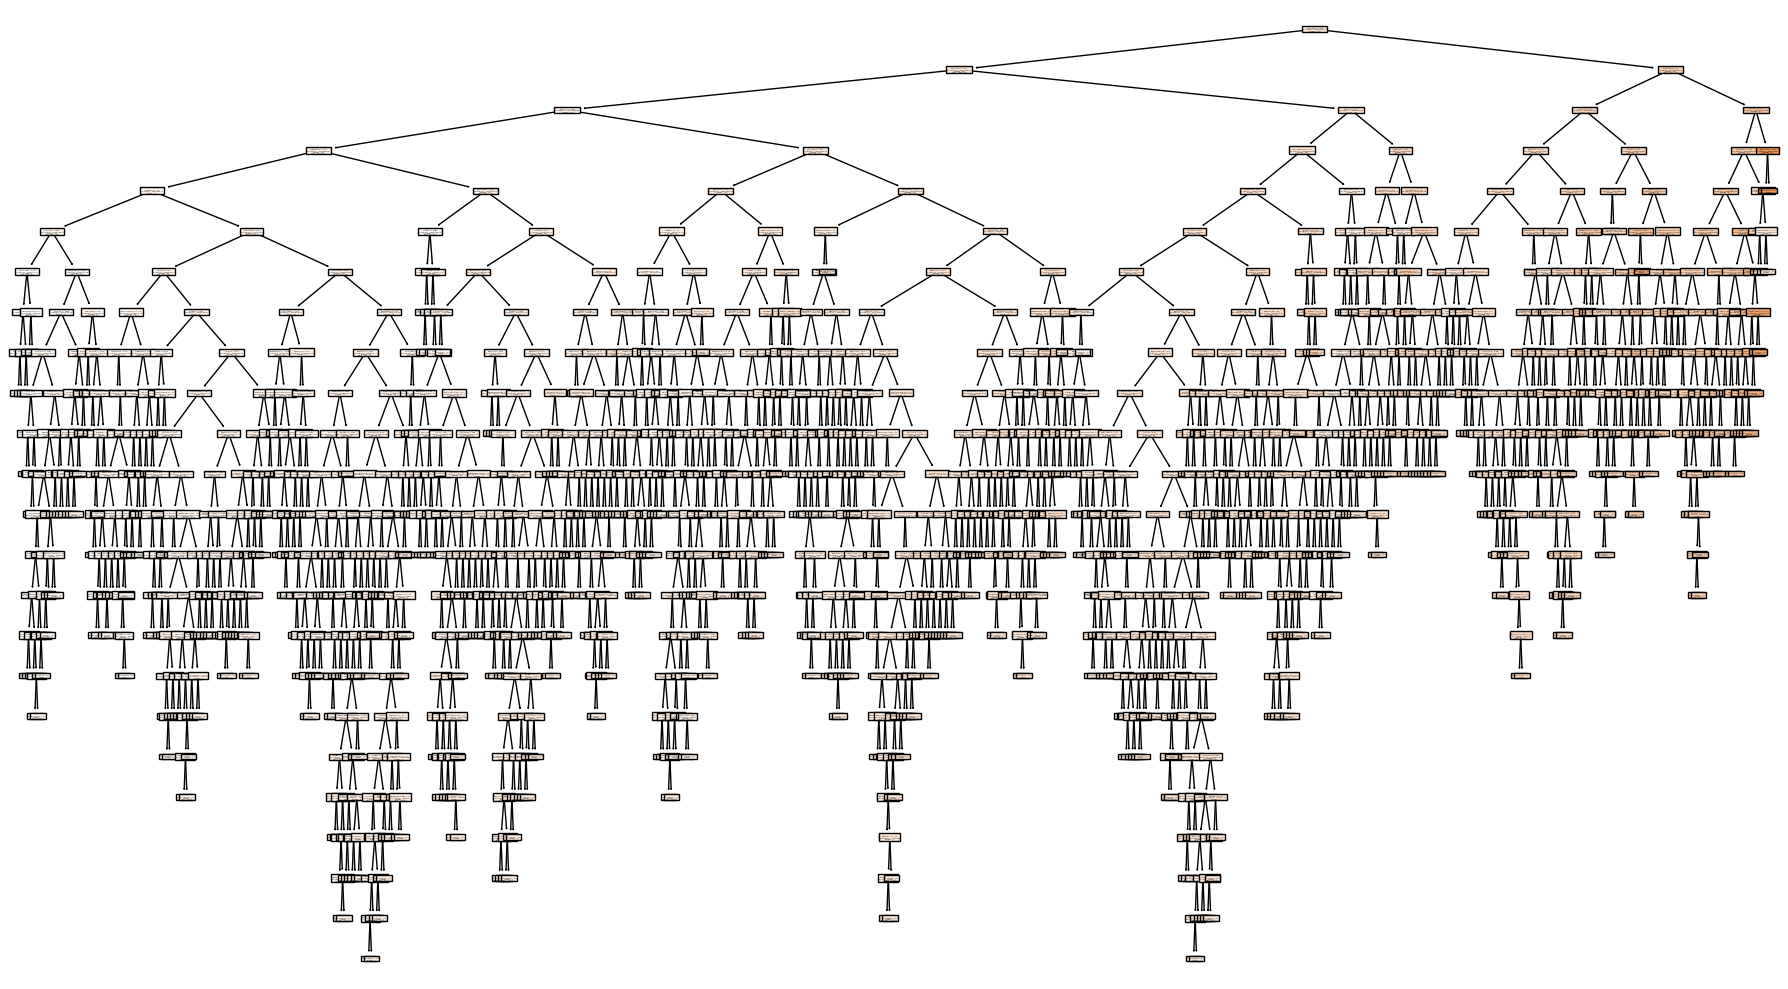

In [79]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 10))

plot_tree(
    dtr,
    feature_names=X.columns,
    filled=True
)

plt.tight_layout()

In [115]:
from sklearn.tree import DecisionTreeRegressor
dtr=DecisionTreeRegressor(max_depth=5,max_leaf_nodes=25)
dtr.fit(X_train,y_train)
y_pred=dtr.predict(X_valid)
print("MAE :", mean_absolute_error(y_valid, y_pred))
print("MSE :", mean_squared_error(y_valid, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_valid, y_pred)))
print("R2  :", r2_score(y_valid, y_pred))



MAE : 27050.68070614047
MSE : 1480801941.4081047
RMSE: 38481.189448977595
R2  : 0.8069440723367687


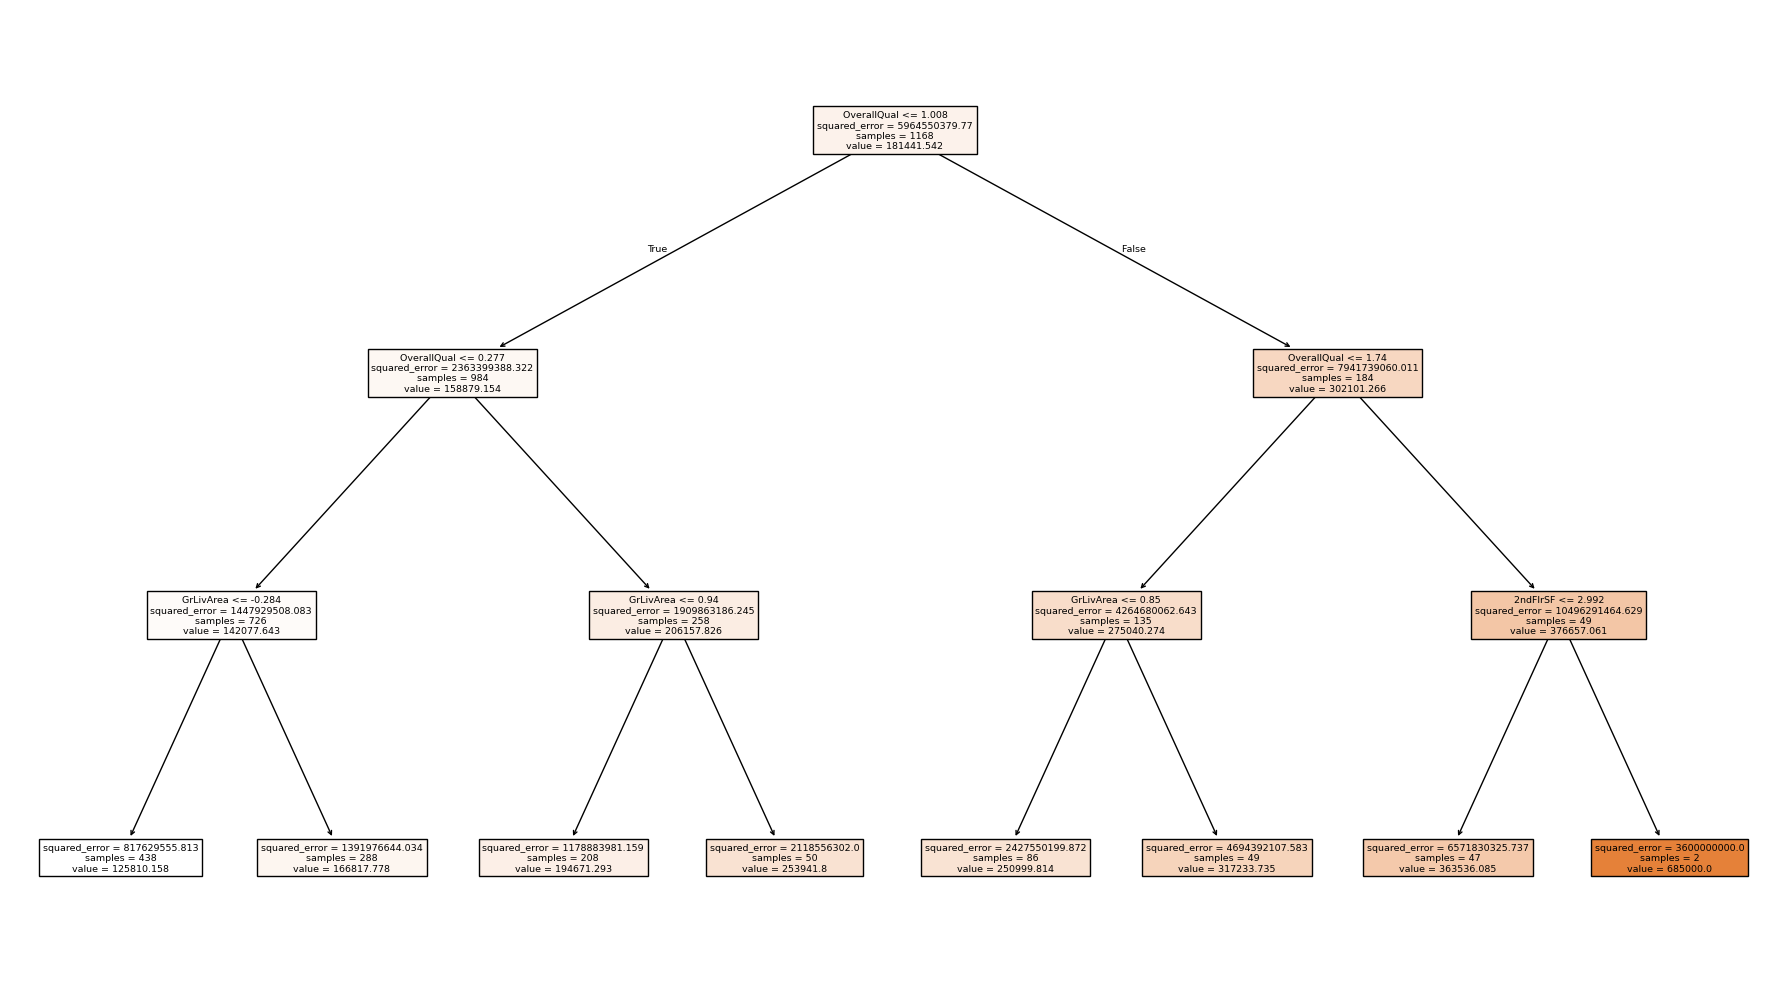

In [89]:
plt.figure(figsize=(18,10))
plot_tree(
    dtr,
    feature_names =X.columns,
    filled=True
)
plt.tight_layout()


In [93]:
from sklearn.ensemble import RandomForestRegressor
rfr=RandomForestRegressor(n_estimators=200,max_depth=5,max_leaf_nodes=25)
rfr.fit(X_train,y_train)
y_pred=rfr.predict(X_valid)
print("MAE :", mean_absolute_error(y_valid, y_pred))
print("MSE :", mean_squared_error(y_valid, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_valid, y_pred)))
print("R2  :", r2_score(y_valid, y_pred))

MAE : 20882.649555399214
MSE : 1074878174.5524578
RMSE: 32785.33474821415
R2  : 0.85986538961729


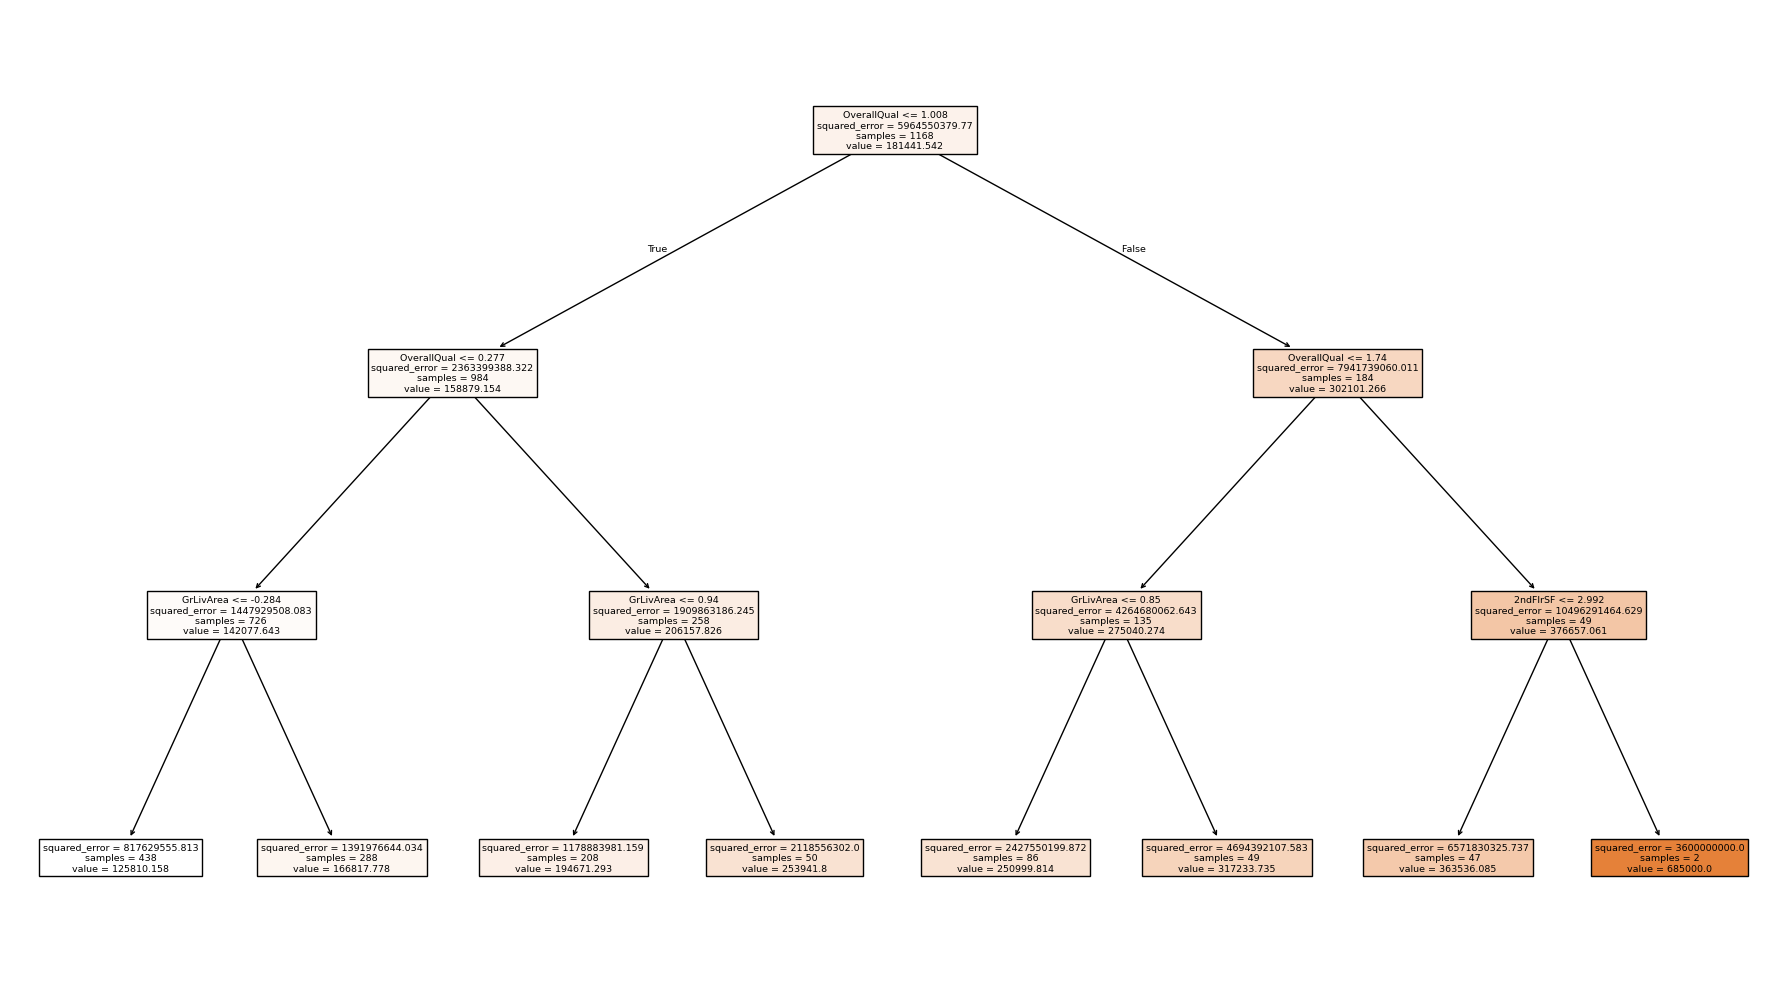

In [94]:
plt.figure(figsize=(18,10))
plot_tree(
    dtr,
    feature_names =X.columns,
    filled=True
)
plt.tight_layout()


In [96]:
from sklearn.ensemble import GradientBoostingRegressor
gbr=GradientBoostingRegressor(learning_rate=0.1, n_estimators=100, subsample=0.8)

gbr.fit(X_train,y_train)
y_pred=gbr.predict(X_valid)
print("MAE :", mean_absolute_error(y_valid, y_pred))
print("MSE :", mean_squared_error(y_valid, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_valid, y_pred)))
print("R2  :", r2_score(y_valid, y_pred))

MAE : 16859.14557290053
MSE : 715170646.0018815
RMSE: 26742.674623191328
R2  : 0.9067613779800181


In [100]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

base = DecisionTreeClassifier(max_depth=5)

model = AdaBoostClassifier(
    estimator=base,
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
model.fit(X_train,y_train)
y_pred=model.predict(X_valid)
print("MAE :", mean_absolute_error(y_valid, y_pred))
print("MSE :", mean_squared_error(y_valid, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_valid, y_pred)))
print("R2  :", r2_score(y_valid, y_pred))

MAE : 30663.11301369863
MSE : 2890391949.6883564
RMSE: 53762.365551455754
R2  : 0.6231722261068835


In [141]:
import xgboost as xgb
model1 = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=42
)
model1.fit(X_train,y_train)
y_pred=model1.predict(X_valid)
print("MAE :", mean_absolute_error(y_valid, y_pred))
print("MSE :", mean_squared_error(y_valid, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_valid, y_pred)))
print("R2  :", r2_score(y_valid, y_pred))

MAE : 17087.268956014555
MSE : 698352213.9608846
RMSE: 26426.354534079885
R2  : 0.9089540398807907


In [117]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
param_grid = {
    "C": [1, 2, 5, 10, 50, 100],
    "kernel": ["rbf", "linear"],
    "epsilon": [0.01, 0.1, 0.2, 0.3, 0.5]
}
svr = SVR()

grid_search = GridSearchCV(svr, param_grid, scoring="r2", cv=5)

grid_search.fit(X_train, y_train)
y_pred=grid_search.predict(X_valid)
print("MAE :", mean_absolute_error(y_valid, y_pred))
print("MSE :", mean_squared_error(y_valid, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_valid, y_pred)))
print("R2  :", r2_score(y_valid, y_pred))

MAE : 19398.548957822775
MSE : 1325008849.0177875
RMSE: 36400.67099680701
R2  : 0.8272552153288801


In [105]:
print("best params - ", grid_search.best_params_)

best params -  {'C': 100, 'epsilon': 0.01, 'kernel': 'linear'}


In [123]:
from sklearn.ensemble import VotingRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

voting = VotingRegressor(
    estimators=[
        ("ridge", Ridge()),
        ("rf", RandomForestRegressor(random_state=42)),
        ("gbr", GradientBoostingRegressor(random_state=42))
    ]
)

voting.fit(X_train, y_train)
y_pred=voting.predict(X_valid)



In [124]:
print("MAE :", mean_absolute_error(y_valid, y_pred))
print("MSE :", mean_squared_error(y_valid, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_valid, y_pred)))
print("R2  :", r2_score(y_valid, y_pred))

MAE : 15959.261832695873
MSE : 711251045.554065
RMSE: 26669.290308406504
R2  : 0.9072723862920432


In [147]:
from sklearn.ensemble import StackingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR

stack = StackingRegressor(
    estimators=[
        ("ridge", Ridge()),
        ("rf", RandomForestRegressor(random_state=42)),
        ("svr", SVR())
    ],
    final_estimator=Ridge(),
    cv=5
)

stack.fit(X_train, y_train)
y_pred=stack.predict(X_valid)

In [149]:
print("MAE :", mean_absolute_error(y_valid, y_pred))
print("MSE :", mean_squared_error(y_valid, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_valid, y_pred)))
print("R2  :", r2_score(y_valid, y_pred))

MAE : 16155.75796158037
MSE : 712565119.9785398
RMSE: 26693.915411167014
R2  : 0.9071010670562012


In [135]:
df_test=pd.read_csv("test.csv")
df_test.isnull().sum().sort_values(ascending=False)

PoolQC           1456
MiscFeature      1408
Alley            1352
Fence            1169
MasVnrType        894
                 ... 
EnclosedPorch       0
MiscVal             0
MoSold              0
YrSold              0
SaleCondition       0
Length: 80, dtype: int64

In [133]:
si=SimpleImputer(strategy="mean")
df_test[num_col]=si.fit_transform(df_test[num_col])
si=SimpleImputer(strategy="most_frequent")
df_test[cat_col]=si.fit_transform(df_test[cat_col])


In [134]:
df_test.isnull().sum().sort_values(ascending=False)

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 81, dtype: int64

In [137]:
df_test=pd.get_dummies(df_test,columns=cat_col,drop_first=True)

In [138]:
# Columns match
df_test = df_test.reindex(columns=X.columns, fill_value=0)

In [ ]:
df_test[num_col]=sc.transform(df_test[num_col])

In [142]:
model1.fit(X,y)
test_pred=model1.predict(df_test)
test_pred


array([120712.02, 162242.33, 175426.95, ..., 167822.36, 132887.48,
       240475.42], shape=(1459,), dtype=float32)

In [146]:
submission = pd.DataFrame({
    "Id": df_test["Id"],
    "SalePrice": test_pred
})

submission.to_csv("submission.csv", index=False)